<a href="https://colab.research.google.com/github/2003UJAN/Laryngeal-Cancer-Few-Shot-Learning-XAI/blob/main/Laryngeal_Cancer_XAI_VGGNET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
!pip install pytorch_metric_learning

In [18]:
!pip install grad-cam

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
from pytorch_metric_learning import losses
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt
from torchvision.models import vgg16
import zipfile
import torch.nn as nn
import torch.optim as optim
from torchvision.models import vgg16 # Import the vgg16 function
import os

In [20]:
zip_path = 'archive.zip'
extract_path = '.'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [21]:
dataset_path = os.path.join(extract_path, 'laryngeal dataset', 'laryngeal dataset')

In [22]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((100, 100)),
    transforms.ToTensor()
])

In [23]:
def load_dataset(root_path, transform):
    return datasets.ImageFolder(root=root_path, transform=transform)

In [24]:
fold1_path = os.path.join(dataset_path, 'FOLD 1')
fold2_path = os.path.join(dataset_path, 'FOLD 2')
fold3_path = os.path.join(dataset_path, 'FOLD 3')

In [25]:
train_data = load_dataset(fold1_path, transform)
val_data = load_dataset(fold2_path, transform)
test_data = load_dataset(fold3_path, transform)

In [26]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [27]:
class VGGNetPrototypicalNetwork(nn.Module):
    def __init__(self, embedding_dim, num_classes):
        super(VGGNetPrototypicalNetwork, self).__init__()
        self.vgg = vgg16(pretrained=True)
        self.vgg.features[0] = nn.Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))

        # Flatten the output of the features
        self.flatten = nn.Flatten()

        # Replace the entire classifier with a new sequential model
        # Calculate the correct input size for the first linear layer
        num_features = self.vgg.features(torch.randn(1, 3, 100, 100)).view(1, -1).size(1) # Assuming image size is 100x100
        self.vgg.classifier = nn.Sequential(
            nn.Linear(num_features, 4096),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(4096, embedding_dim)
        )

        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, x):
        features = self.vgg.features(x)
        features = self.flatten(features) # Flatten the features
        embeddings = self.vgg.classifier(features)
        logits = self.classifier(embeddings)
        return logits

In [28]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [29]:
embedding_dim = 64
num_classes = len(train_data.classes)
model = VGGNetPrototypicalNetwork(embedding_dim, num_classes).to(device)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.7)
criterion = nn.CrossEntropyLoss()

In [14]:
def compute_accuracy(loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            predictions = torch.argmax(logits, dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    return correct / total

for epoch in range(45):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    scheduler.step()
    train_acc = compute_accuracy(train_loader)
    val_acc = compute_accuracy(val_loader)

    print(f'Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}, '
          f'Train Accuracy: {train_acc*100:.2f}%, Val Accuracy: {val_acc*100:.2f}%')

test_acc = compute_accuracy(test_loader)
print(f'Test Accuracy: {test_acc*100:.2f}%')

Epoch 1, Loss: 1.524431824684143, Train Accuracy: 25.00%, Val Accuracy: 25.00%
Epoch 2, Loss: 1.4895134227616447, Train Accuracy: 25.23%, Val Accuracy: 26.14%
Epoch 3, Loss: 1.334845585482461, Train Accuracy: 34.32%, Val Accuracy: 32.05%
Epoch 4, Loss: 1.2177586129733495, Train Accuracy: 30.68%, Val Accuracy: 30.91%
Epoch 5, Loss: 1.3267009939466203, Train Accuracy: 47.95%, Val Accuracy: 44.77%
Epoch 6, Loss: 1.0890101960727148, Train Accuracy: 46.82%, Val Accuracy: 41.36%
Epoch 7, Loss: 1.004365588937487, Train Accuracy: 48.64%, Val Accuracy: 44.55%
Epoch 8, Loss: 0.9398343946252551, Train Accuracy: 56.82%, Val Accuracy: 48.64%
Epoch 9, Loss: 0.9045102340834481, Train Accuracy: 46.82%, Val Accuracy: 39.77%
Epoch 10, Loss: 1.4244767810617174, Train Accuracy: 43.18%, Val Accuracy: 37.50%
Epoch 11, Loss: 0.9891077620642525, Train Accuracy: 53.86%, Val Accuracy: 46.59%
Epoch 12, Loss: 0.8972013337271554, Train Accuracy: 56.36%, Val Accuracy: 48.86%
Epoch 13, Loss: 0.845067241362163, Train

In [30]:
def generate_gradcam(model, image, target_layer):
    model.eval()
    if image.shape[0] != model.vgg.features[0].weight.shape[1]:
        image = image.repeat(model.vgg.features[0].weight.shape[1], 1, 1)
    cam = GradCAM(model=model, target_layers=[target_layer])
    grayscale_cam = cam(input_tensor=image.unsqueeze(0))[0, :]
    image = image.permute(1, 2, 0).cpu().numpy()
    cam_image = show_cam_on_image(image, grayscale_cam, use_rgb=True)
    return cam_image

In [32]:
test_iter = iter(test_loader)
images, labels = next(test_iter)
image = images[0].to(device)
target_layer = model.vgg.features[-1]
cam_image = generate_gradcam(model, image, target_layer)

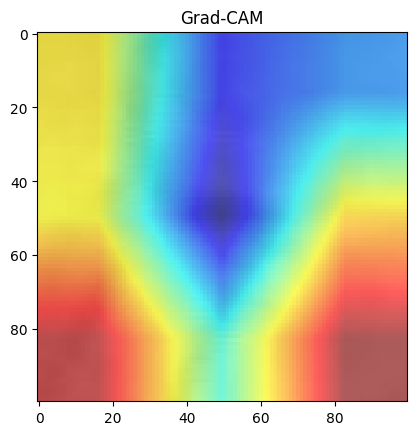

In [33]:
plt.imshow(cam_image)
plt.title('Grad-CAM')
plt.show()